<a href="https://colab.research.google.com/github/Chandana-dharshanam/ecg-detection/blob/main/ecg-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 30.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [ ]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("WFDB Version:", wfdb.__version__)
print("Pandas Version:", pd.__version__)

WFDB Version: 4.3.1
Pandas Version: 3.0.5


In [ ]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')

print(record.record_name)

100


In [ ]:
print(type(record))


<class 'wfdb.io.record.Record'>


In [ ]:
dir(record)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_datetime',
 '_arrange_fields',
 '_auto_signal_file_names',
 'adc',
 'adc_gain',
 'adc_res',
 'adc_zero',
 'base_counter',
 'base_date',
 'base_datetime',
 'base_time',
 'baseline',
 'block_size',
 'byte_offset',
 'calc_adc_gain_baseline',
 'calc_adc_params',
 'calc_checksum',
 'check_field',
 'check_field_cohesion',
 'check_read_inputs',
 'check_sig_cohesion',
 'checksum',
 'comments',
 'convert_dtype',
 'counter_freq',
 'd_signal',
 'dac',
 'e_d_signal',
 'e_p_signal',
 'file_name',
 'fmt',
 'fs',
 'get_absolute_time',
 'get_elapsed_time',
 'get_frame_number',
 'get_write_fields',
 'get_write_su

In [ ]:
print(record.record_name)


100


In [ ]:
#sampling frequency
print(record.fs)


360


In [ ]:
#ECG leads
print(record.sig_name)


['MLII', 'V5']


In [ ]:
#measures of ecg signals
print(record.units)


['mV', 'mV']


In [ ]:
#(measuements,ecg leads)
print(record.p_signal.shape)

(650000, 2)


In [ ]:
ecg = record.p_signal[:,0]
print(type(ecg))

<class 'numpy.ndarray'>


In [ ]:
print(ecg.shape)

(650000,)


In [ ]:
print(ecg[:10])

[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


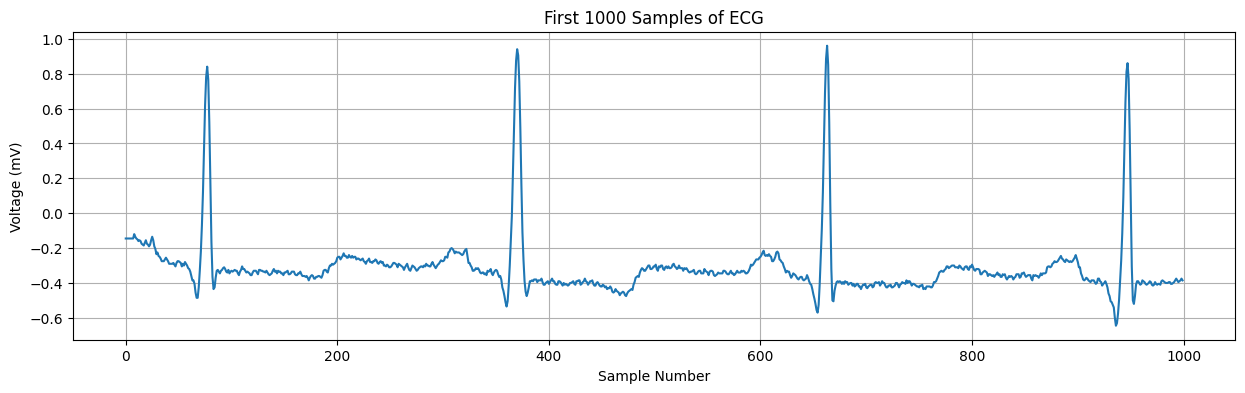

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(ecg[:1000])

plt.title("First 1000 Samples of ECG")

plt.xlabel("Sample Number")

plt.ylabel("Voltage (mV)")

plt.grid(True)

plt.show()

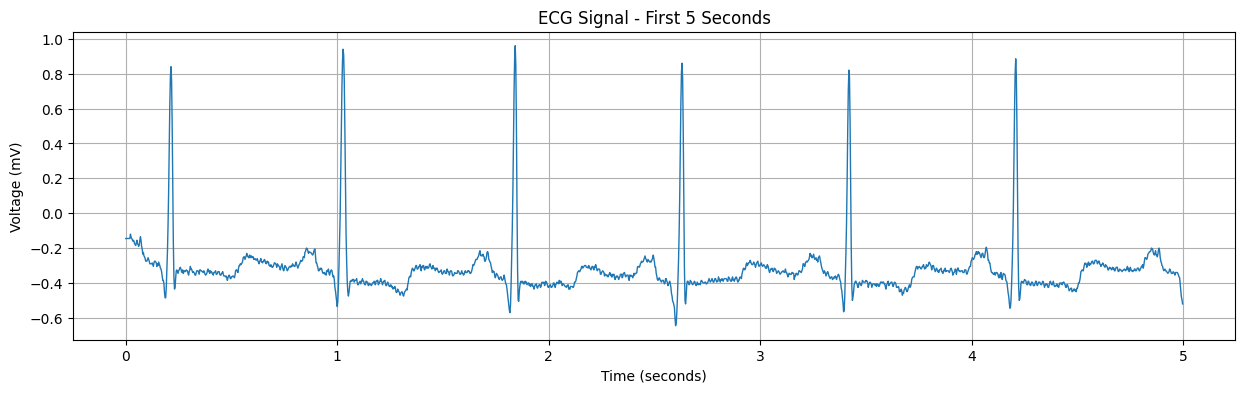

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract MLII lead
ecg = record.p_signal[:, 0]

# Create time axis
time = np.arange(len(ecg)) / record.fs

# Plot first 5 seconds
duration = 5  # seconds
samples = int(duration * record.fs)

plt.figure(figsize=(15,4))
plt.plot(time[:samples], ecg[:samples], linewidth=1)

plt.title(f"ECG Signal - First {duration} Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [ ]:
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
print(type(annotation))

<class 'wfdb.io.annotation.Annotation'>


In [ ]:
print(annotation.sample[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [ ]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [ ]:
print(len(annotation.sample))

2274


In [ ]:
print(len(annotation.symbol))

2274


In [ ]:
#time=sample/360
for sample, symbol in zip(annotation.sample[:20], annotation.symbol[:20]):
    print(sample, symbol)

18 +
77 N
370 N
662 N
946 N
1231 N
1515 N
1809 N
2044 A
2402 N
2706 N
2998 N
3282 N
3560 N
3862 N
4170 N
4466 N
4764 N
5060 N
5346 N


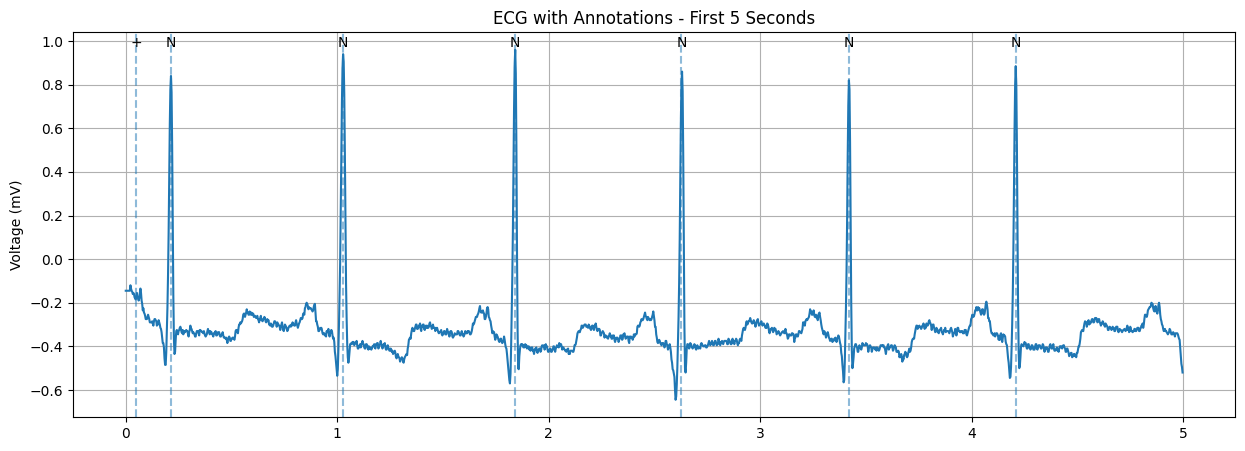

In [ ]:
import matplotlib.pyplot as plt

# First 5 seconds
duration = 5
samples = int(duration * record.fs)

# Get annotations that occur within the first 5 seconds
mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

# Convert annotation sample numbers to time
ann_times = ann_samples / record.fs

# Plot ECG
plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

# Mark annotations
for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 5 Seconds")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

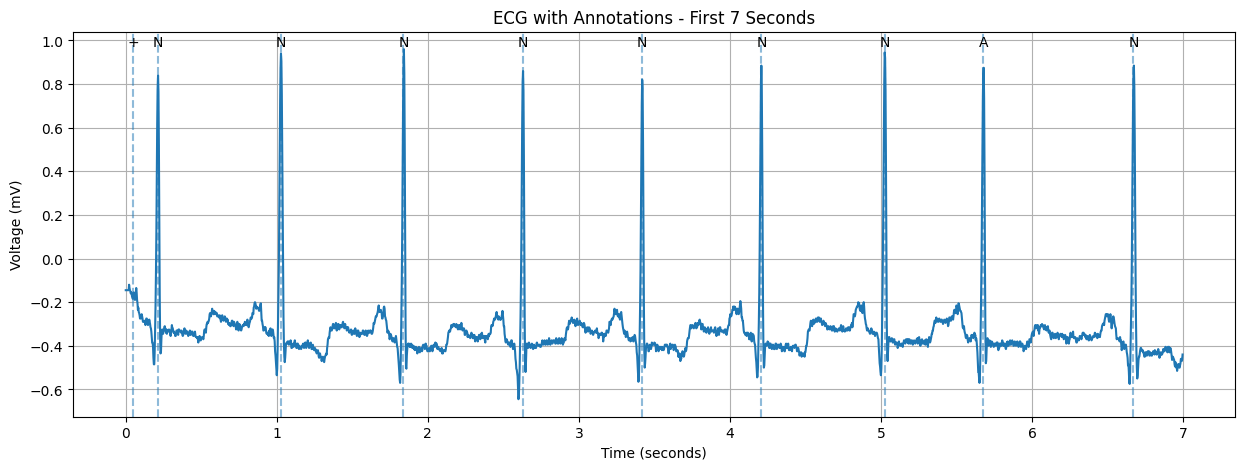

In [ ]:
duration = 7
samples = int(duration * record.fs)

mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

ann_times = ann_samples / record.fs

plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 7 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [ ]:
#Band pass Filter
from scipy.signal import butter, filtfilt

# Sampling frequency
fs = record.fs

# Filter settings
low_cutoff = 0.5
high_cutoff = 40

# Create a 4th-order Butterworth band-pass filter
b, a = butter(
    4,
    [low_cutoff, high_cutoff],
    btype='bandpass',
    fs=fs
)

# Apply the filter
ecg_filtered = filtfilt(b, a, ecg)

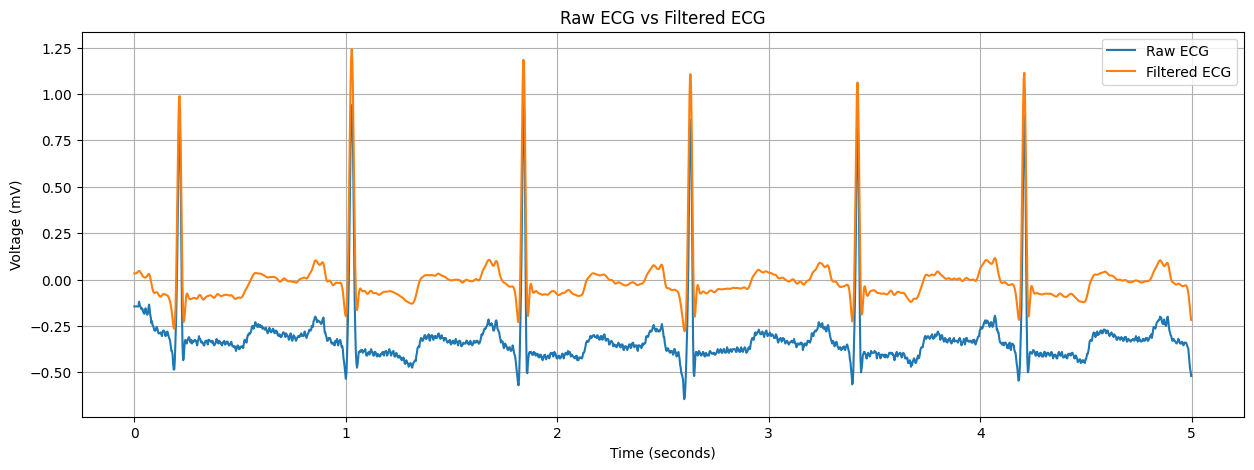

In [ ]:
duration = 5
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg[:samples], label="Raw ECG")
plt.plot(time[:samples], ecg_filtered[:samples], label="Filtered ECG")

plt.title("Raw ECG vs Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

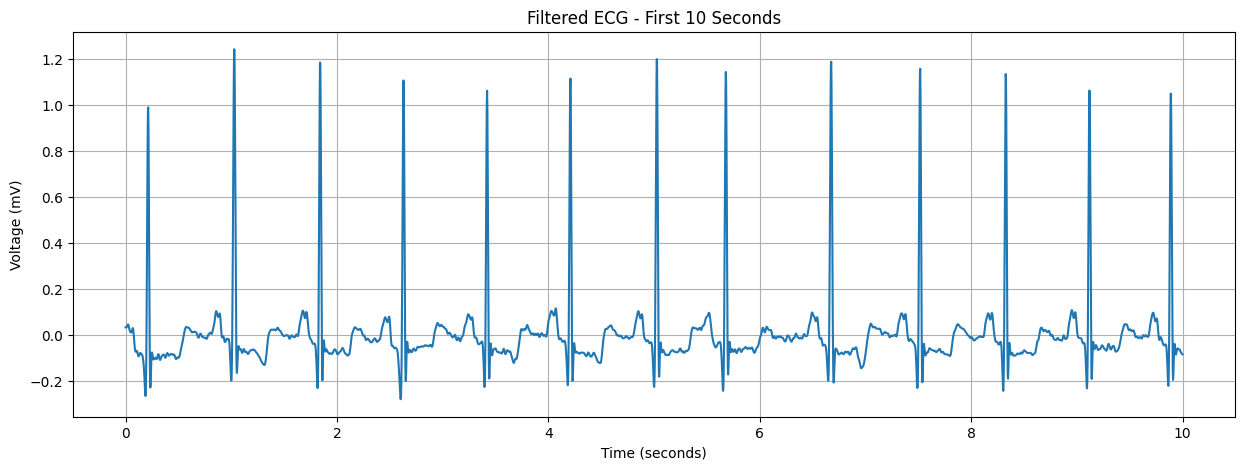

In [ ]:
duration = 10
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg_filtered[:samples])

plt.title("Filtered ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

In [ ]:
from scipy.signal import find_peaks

r_peaks, properties = find_peaks(
    ecg_filtered,
    distance=int(0.25 * fs),
    prominence=0.5
)

print("Number of detected R-peaks:", len(r_peaks))
print("First 20 detected R-peaks:", r_peaks[:20])

Number of detected R-peaks: 2273
First 20 detected R-peaks: [  77  370  662  947 1231 1515 1809 2044 2403 2706 2997 3282 3559 3862
 4170 4466 4764 5060 5346 5634]


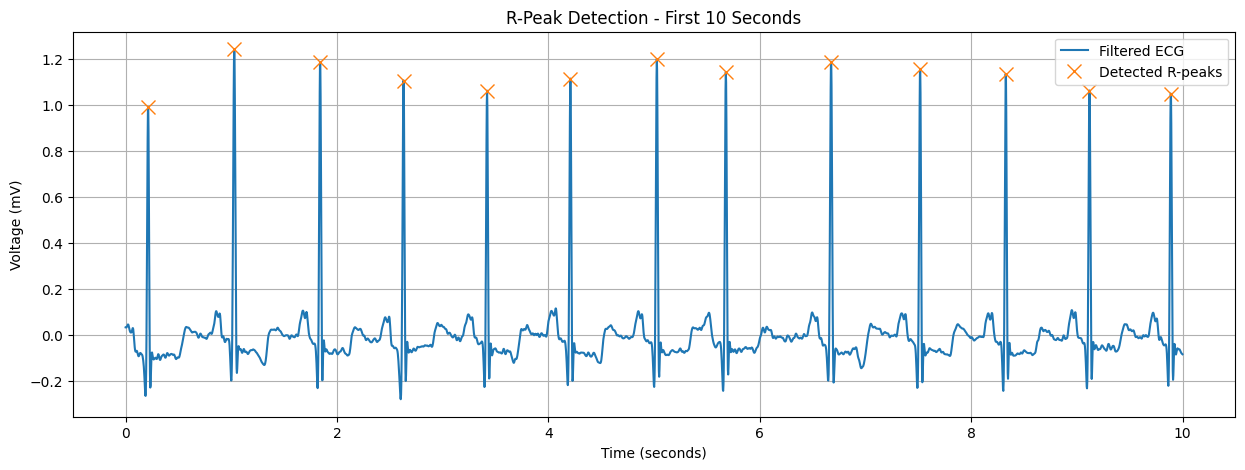

In [ ]:
#R-peak Detection
duration = 10
samples = int(duration * fs)

# Only peaks within the first 10 seconds
peaks_10s = r_peaks[r_peaks < samples]

plt.figure(figsize=(15, 5))

plt.plot(
    time[:samples],
    ecg_filtered[:samples],
    label="Filtered ECG"
)

plt.plot(
    time[peaks_10s],
    ecg_filtered[peaks_10s],
    'x',
    markersize=10,
    label="Detected R-peaks"
)

plt.title("R-Peak Detection - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
r_peak_times = r_peaks / fs

print("First 20 R-peak times:")
print(r_peak_times[:20])

First 20 R-peak times:
[ 0.21388889  1.02777778  1.83888889  2.63055556  3.41944444  4.20833333
  5.025       5.67777778  6.675       7.51666667  8.325       9.11666667
  9.88611111 10.72777778 11.58333333 12.40555556 13.23333333 14.05555556
 14.85       15.65      ]


In [ ]:
#Expert annotations vs our detected R-peaks.
# Expert annotation samples in first 10 seconds
annotation_samples_10s = annotation.sample[
    annotation.sample < int(10 * fs)
]

annotation_symbols_10s = np.array(annotation.symbol)[
    annotation.sample < int(10 * fs)
]

print("Expert annotations:")
for sample, symbol in zip(annotation_samples_10s, annotation_symbols_10s):
    print(f"Sample: {sample:4d} | Time: {sample/fs:.4f} s | Label: {symbol}")

Expert annotations:
Sample:   18 | Time: 0.0500 s | Label: +
Sample:   77 | Time: 0.2139 s | Label: N
Sample:  370 | Time: 1.0278 s | Label: N
Sample:  662 | Time: 1.8389 s | Label: N
Sample:  946 | Time: 2.6278 s | Label: N
Sample: 1231 | Time: 3.4194 s | Label: N
Sample: 1515 | Time: 4.2083 s | Label: N
Sample: 1809 | Time: 5.0250 s | Label: N
Sample: 2044 | Time: 5.6778 s | Label: A
Sample: 2402 | Time: 6.6722 s | Label: N
Sample: 2706 | Time: 7.5167 s | Label: N
Sample: 2998 | Time: 8.3278 s | Label: N
Sample: 3282 | Time: 9.1167 s | Label: N
Sample: 3560 | Time: 9.8889 s | Label: N


In [ ]:
print("\nDetected R-peaks:")
for peak in r_peaks[r_peaks < int(10 * fs)]:
    print(f"Sample: {peak:4d} | Time: {peak/fs:.4f} s")


Detected R-peaks:
Sample:   77 | Time: 0.2139 s
Sample:  370 | Time: 1.0278 s
Sample:  662 | Time: 1.8389 s
Sample:  947 | Time: 2.6306 s
Sample: 1231 | Time: 3.4194 s
Sample: 1515 | Time: 4.2083 s
Sample: 1809 | Time: 5.0250 s
Sample: 2044 | Time: 5.6778 s
Sample: 2403 | Time: 6.6750 s
Sample: 2706 | Time: 7.5167 s
Sample: 2997 | Time: 8.3250 s
Sample: 3282 | Time: 9.1167 s
Sample: 3559 | Time: 9.8861 s
